<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/01_CBIS_DDSM_Preparation_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Add Kaggle.json**

In [1]:
import json
import os
from google.colab import userdata

In [2]:
# Get Kaggle Data from Colab Secrets
kaggle_data = {
    "username": userdata.get('KAGGLE_USERNAME'),
    "key": userdata.get('KAGGLE_KEY')
}

# Create directory for .kaggle
!mkdir -p ~/.kaggle
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_data, f)

# Change permission for safety
!chmod 600 ~/.kaggle/kaggle.json

print("kaggle.json is ready!")

kaggle.json is ready!


# **Download the CBIS-DDSM directly from Kaggle**

In [3]:
import zipfile

In [4]:

# Download dataset
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset

# Extract dataset
extract_dir = "cbis_ddsm_awsaf"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(
        "cbis-ddsm-breast-cancer-image-dataset.zip",
        "r"
    ) as zip_ref:
        zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [01:01<00:00, 86.3MB/s]

Dataset extracted to: cbis_ddsm_awsaf


# **Import Libraries**

In [5]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

# **Dataset Preparation**

### **Dataset Path**

In [6]:
ROOT = Path("cbis_ddsm_awsaf")

JPEG_DIR = ROOT / "jpeg"
CSV_DIR = ROOT / "csv"

MASS_TRAIN = CSV_DIR / "mass_case_description_train_set.csv"
MASS_TEST  = CSV_DIR / "mass_case_description_test_set.csv"

CALC_TRAIN = CSV_DIR / "calc_case_description_train_set.csv"
CALC_TEST  = CSV_DIR / "calc_case_description_test_set.csv"

### **Keep Only Full Mammogram**

In [7]:
full_images = []

for img in JPEG_DIR.rglob("*.jpg"):

    if img.name.startswith("1-"):

        full_images.append(str(img))

len(full_images)

6774

### **Dataframe Images**

In [8]:
df_images = pd.DataFrame({
    "image_path": full_images
})

df_images.head()

,image_path
0,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
1,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
2,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
3,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
4,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....


### **Visualization**

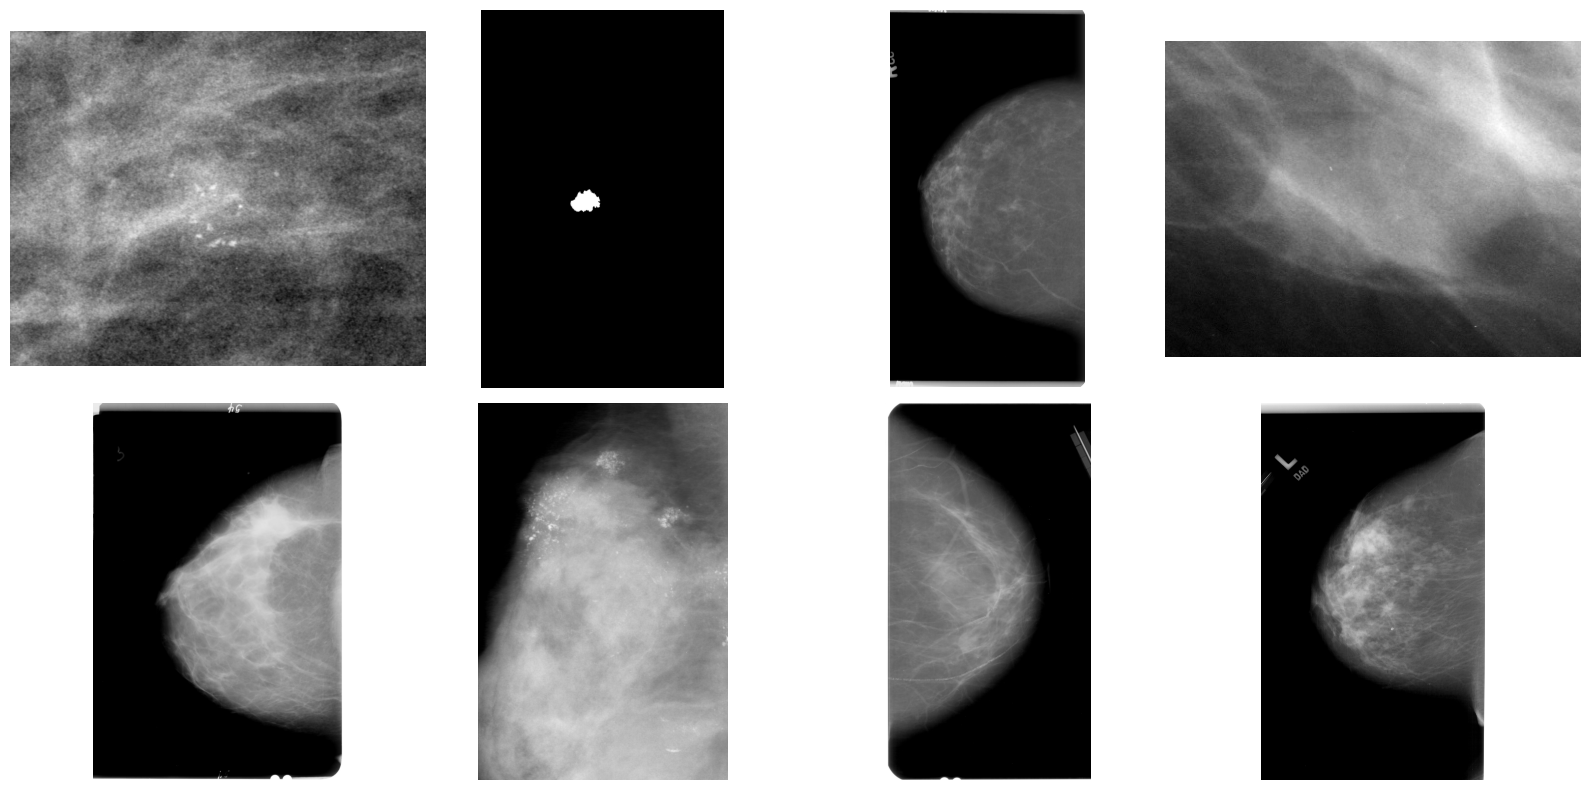

In [9]:
fig, axes = plt.subplots(2,4, figsize=(16,8))

for ax, img_path in zip(axes.flatten(),
                        df_images.sample(8).image_path):

    img = Image.open(img_path)

    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.tight_layout()

### **Load All Annotations**

In [10]:
mass_train = pd.read_csv(MASS_TRAIN)
mass_test  = pd.read_csv(MASS_TEST)

calc_train = pd.read_csv(CALC_TRAIN)
calc_test  = pd.read_csv(CALC_TEST)

df_ann = pd.concat([
    mass_train,
    mass_test,
    calc_train,
    calc_test
], ignore_index=True)

print(df_ann.shape)

(3568, 17)


### **Create DataFrame for JPEG**

In [11]:
from pathlib import Path
import pandas as pd

jpeg_root = Path("cbis_ddsm_awsaf/jpeg")

records = []

for patient_folder in jpeg_root.iterdir():

    if not patient_folder.is_dir():
        continue

    jpgs = sorted(patient_folder.glob("*.jpg"))

    for img in jpgs:

        records.append({
            "folder": patient_folder.name,
            "image_path": str(img),
        })

jpeg_df = pd.DataFrame(records)

print(jpeg_df.shape)
jpeg_df.head()

(10237, 2)


,folder,image_path
0,1.3.6.1.4.1.9590.100.1.2.113088658712941187126...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
1,1.3.6.1.4.1.9590.100.1.2.106104394513551099319...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
2,1.3.6.1.4.1.9590.100.1.2.112531512011689200704...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
3,1.3.6.1.4.1.9590.100.1.2.112531512011689200704...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
4,1.3.6.1.4.1.9590.100.1.2.760058159117455127016...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....


In [13]:
for f in sorted(Path("cbis_ddsm_awsaf").rglob("*.csv")):
    print(f)

for f in sorted(Path("cbis_ddsm_awsaf").rglob("*.parquet")):
    print(f)

for f in sorted(Path("cbis_ddsm_awsaf").rglob("*.json")):
    print(f)

cbis_ddsm_awsaf/csv/calc_case_description_test_set.csv
cbis_ddsm_awsaf/csv/calc_case_description_train_set.csv
cbis_ddsm_awsaf/csv/dicom_info.csv
cbis_ddsm_awsaf/csv/mass_case_description_test_set.csv
cbis_ddsm_awsaf/csv/mass_case_description_train_set.csv
cbis_ddsm_awsaf/csv/meta.csv


In [19]:
DICOM_INFO = CSV_DIR / "dicom_info.csv"

dicom = pd.read_csv(DICOM_INFO)

In [27]:
dicom.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [20]:
dicom[[
    "file_path",
    "image_path"
]].head(5)

,file_path,image_path
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...


In [24]:
sample = df_ann.iloc[0]["image file path"]

print(sample)

parts = sample.split("/")

print(parts)

Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
['Mass-Training_P_00001_LEFT_CC', '1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994', '1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515', '000000.dcm']


In [26]:
sample = df_ann.iloc[1]["image file path"]

print(sample)

parts = sample.split("/")

print(parts)

Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/000000.dcm
['Mass-Training_P_00001_LEFT_MLO', '1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988', '1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834', '000000.dcm']


In [25]:
print(dicom[[
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "SOPInstanceUID"
]].head())

                                    StudyInstanceUID  \
0  1.3.6.1.4.1.9590.100.1.2.271867287611061855725...   
1  1.3.6.1.4.1.9590.100.1.2.161516517311681906612...   
2  1.3.6.1.4.1.9590.100.1.2.291043622711253836701...   
3  1.3.6.1.4.1.9590.100.1.2.335006093711888937440...   
4  1.3.6.1.4.1.9590.100.1.2.335006093711888937440...   

                                   SeriesInstanceUID  \
0  1.3.6.1.4.1.9590.100.1.2.129308726812851964007...   
1  1.3.6.1.4.1.9590.100.1.2.248386742010678582309...   
2  1.3.6.1.4.1.9590.100.1.2.267213171011171858918...   
3  1.3.6.1.4.1.9590.100.1.2.381187369611524586537...   
4  1.3.6.1.4.1.9590.100.1.2.381187369611524586537...   

                                      SOPInstanceUID  
0  1.3.6.1.4.1.9590.100.1.2.426380754911844882201...  
1  1.3.6.1.4.1.9590.100.1.2.235715018911442345533...  
2  1.3.6.1.4.1.9590.100.1.2.212917405611495375422...  
3  1.3.6.1.4.1.9590.100.1.2.405776661412249467913...  
4  1.3.6.1.4.1.9590.100.1.2.418434643810489919922..

In [28]:
uid1 = parts[1]
uid2 = parts[2]

print("UID1")
print(uid1)

print()

print("Series matches")
print((dicom["SeriesInstanceUID"] == uid1).sum())

print("Study matches")
print((dicom["StudyInstanceUID"] == uid1).sum())

print("SOP matches")
print((dicom["SOPInstanceUID"] == uid1).sum())

print("\n========================\n")

print("UID2")
print(uid2)

print()

print("Series matches")
print((dicom["SeriesInstanceUID"] == uid2).sum())

print("Study matches")
print((dicom["StudyInstanceUID"] == uid2).sum())

print("SOP matches")
print((dicom["SOPInstanceUID"] == uid2).sum())

UID1
1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988

Series matches
0
Study matches
1
SOP matches
0


UID2
1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834

Series matches
1
Study matches
0
SOP matches
0


### **Ekstrak UID from Annotation CSV**

In [29]:
def extract_uids(path):

    parts = path.split("/")

    return pd.Series({
        "StudyInstanceUID": parts[1],
        "SeriesInstanceUID": parts[2]
    })

df_uid = df_ann["image file path"].apply(extract_uids)

df_ann = pd.concat(
    [df_ann, df_uid],
    axis=1
)

df_ann.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution,StudyInstanceUID,SeriesInstanceUID
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.422112722213189649807...,1.3.6.1.4.1.9590.100.1.2.342386194811267636608...
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.319478999311971442426...,1.3.6.1.4.1.9590.100.1.2.359308329312397897125...
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.347107867812656628709...,1.3.6.1.4.1.9590.100.1.2.891800462110225318343...
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.272600286511817402806...,1.3.6.1.4.1.9590.100.1.2.295360926313492745441...
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.174047308712169195014...,1.3.6.1.4.1.9590.100.1.2.410524754913057908920...


### **Mapping from dicom_info**

In [30]:
mapping = dicom[
    [
        "StudyInstanceUID",
        "SeriesInstanceUID",
        "image_path"
    ]
].drop_duplicates()

mapping.head()

,StudyInstanceUID,SeriesInstanceUID,image_path
0,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...
1,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
3,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
4,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...


### **Merge**

In [31]:
df = df_ann.merge(
    mapping,
    on=[
        "StudyInstanceUID",
        "SeriesInstanceUID"
    ],
    how="left"
)

print(df.shape)

print("Missing image:",
      df["image_path"].isna().sum())

(3568, 20)
Missing image: 0


### **Convert JPEG Path into local path**

In [32]:
df["image_path"] = (
    "cbis_ddsm_awsaf/"
    + df["image_path"].str.replace(
        "CBIS-DDSM/",
        "",
        regex=False
    )
)

df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution,StudyInstanceUID,SeriesInstanceUID,image_path
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.422112722213189649807...,1.3.6.1.4.1.9590.100.1.2.342386194811267636608...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.319478999311971442426...,1.3.6.1.4.1.9590.100.1.2.359308329312397897125...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.347107867812656628709...,1.3.6.1.4.1.9590.100.1.2.891800462110225318343...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.272600286511817402806...,1.3.6.1.4.1.9590.100.1.2.295360926313492745441...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,NaN,NaN,NaN,1.3.6.1.4.1.9590.100.1.2.174047308712169195014...,1.3.6.1.4.1.9590.100.1.2.410524754913057908920...,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....


In [33]:
df["exists"] = df["image_path"].apply(
    lambda x: Path(x).exists()
)

print(df["exists"].value_counts())

exists
True    3568
Name: count, dtype: int64


### **Define Label**

In [34]:
df["cancer"] = (
    df["pathology"]
      .str.upper()
      .eq("MALIGNANT")
      .astype(int)
)

df["cancer"].value_counts()

,count
cancer,
0,2111
1,1457


### **Check whether UID pairing are unique or not**

In [35]:
mapping.groupby(
    [
        "StudyInstanceUID",
        "SeriesInstanceUID"
    ]
).size().value_counts()

,count
2,3463
1,3311


### **Check the Merge**

In [36]:
print(df_ann.shape)

(3568, 19)


In [37]:
print(df.shape)

(3568, 22)


In [38]:
df["image_path"].value_counts().head(20)

,count
image_path,
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.129791061511313973927878918694190000311/1-018.jpg,7
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.329104735012234553414142104453590990063/1-277.jpg,7
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.385993857812880492226944782470456885854/1-276.jpg,6
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.180179872111889546935977772832474436349/1-118.jpg,6
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.349750807312790393730055294924200427235/1-041.jpg,6
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.226337463110875594101666175242078490747/1-275.jpg,6
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.394064951611063352439533738582020635502/1-062.jpg,6
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.412965116411834959031936355110915022364/1-061.jpg,6
cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2.413719783912934165841599750420836099995/1-060.jpg,6


### **Check Missing Image**

In [39]:
print(df["image_path"].isna().sum())

print(df["exists"].value_counts())

0
exists
True    3568
Name: count, dtype: int64


### **Random Visualization**

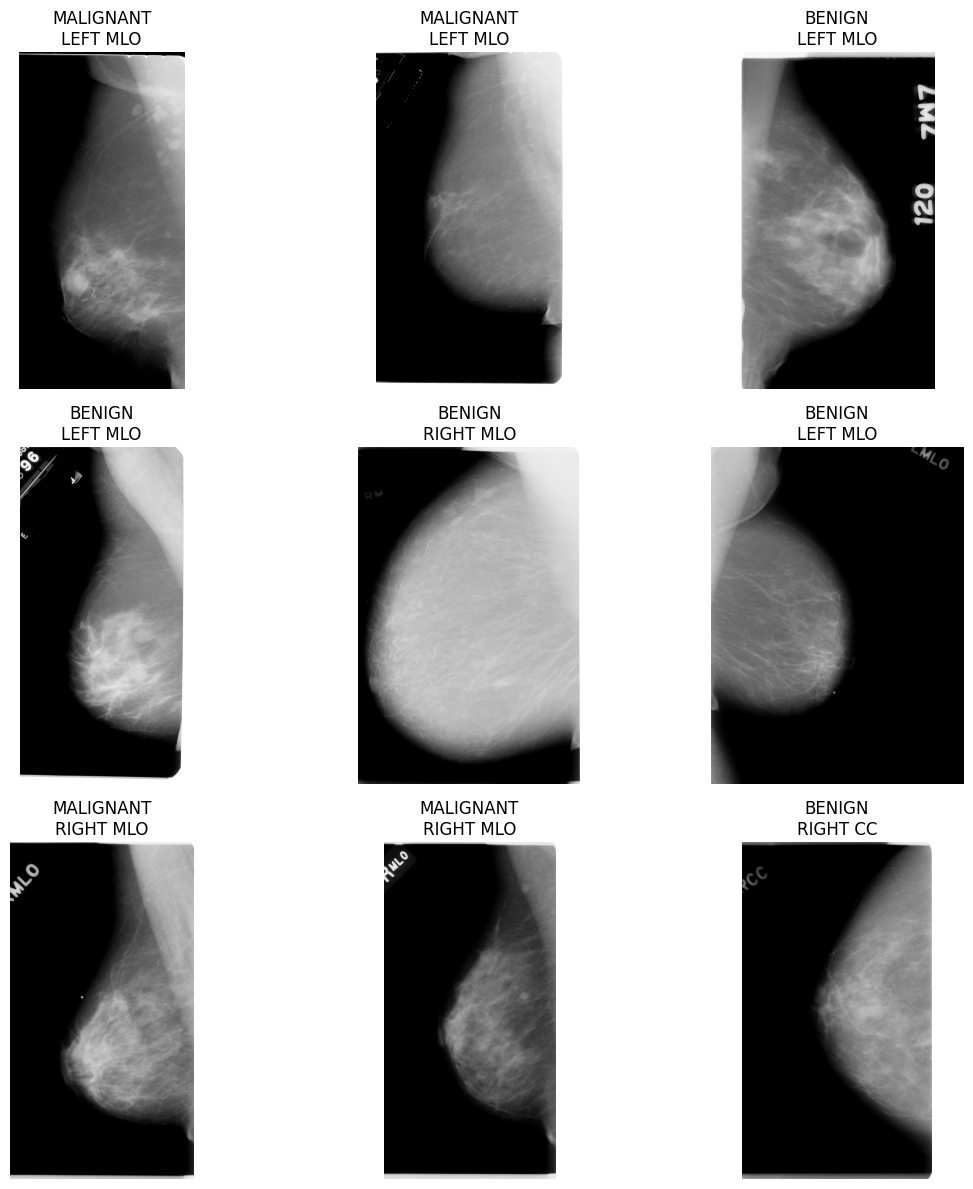

In [40]:
import matplotlib.pyplot as plt
from PIL import Image

sample = df.sample(
    9,
    random_state=42
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(12,12)
)

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):

    img = Image.open(row["image_path"])

    ax.imshow(img, cmap="gray")

    ax.set_title(
        f"{row['pathology']}\n"
        f"{row['left or right breast']} {row['image view']}"
    )

    ax.axis("off")

plt.tight_layout()

### **Image-level DataFrame**

In [41]:
df_img = (
    df
    .groupby(
        [
            "image_path",
            "patient_id",
            "left or right breast",
            "image view"
        ],
        as_index=False
    )
    .agg(
        cancer=("cancer","max")
    )
)

In [42]:
print(df_img.shape)

print(df_img["cancer"].value_counts())

(3103, 5)
cancer
0    1728
1    1375
Name: count, dtype: int64


### **Check Duplication**

In [43]:
print(df_img["image_path"].duplicated().sum())

0


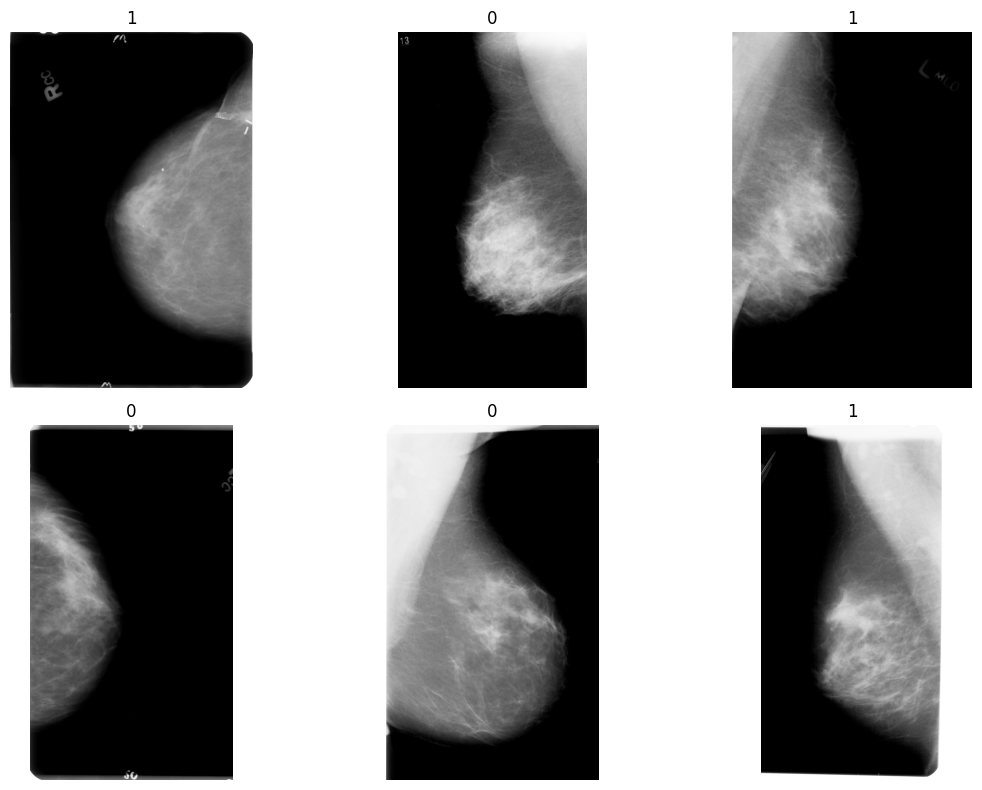

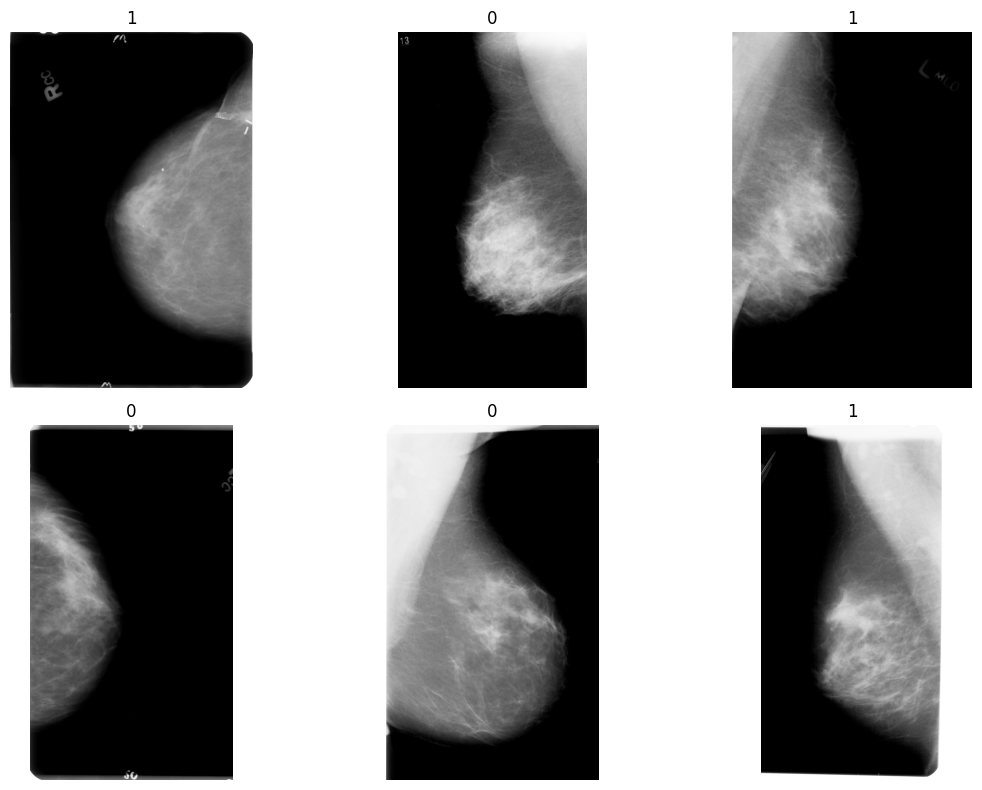

In [46]:
import cv2

sample = df_img.sample(6, random_state=42)

fig, ax = plt.subplots(2,3, figsize=(12,8))

for a, (_, row) in zip(ax.flatten(), sample.iterrows()):

    img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)

    a.imshow(img, cmap="gray")

    a.set_title(
        f"{row['cancer']}"
    )

    a.axis("off")

plt.tight_layout()

sample = df_img.sample(6, random_state=42)

fig, ax = plt.subplots(2,3, figsize=(12,8))

for a, (_, row) in zip(ax.flatten(), sample.iterrows()):

    img = cv2.imread(row.image_path, cv2.IMREAD_GRAYSCALE)

    a.imshow(img, cmap="gray")

    a.set_title(
        f"{row['cancer']}"
    )

    a.axis("off")

plt.tight_layout()

### **Patient-level Group Split**


In [47]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, val_idx = next(
    sgkf.split(
        X=df_img,
        y=df_img["cancer"],
        groups=df_img["patient_id"]
    )
)

train_df = (
    df_img
    .iloc[train_idx]
    .reset_index(drop=True)
)

val_df = (
    df_img
    .iloc[val_idx]
    .reset_index(drop=True)
)

In [48]:
print("Train :", train_df.shape)
print("Valid :", val_df.shape)

print("\nTrain label distribution")
print(train_df["cancer"].value_counts())

print("\nValidation label distribution")
print(val_df["cancer"].value_counts())

Train : (2482, 5)
Valid : (621, 5)

Train label distribution
cancer
0    1394
1    1088
Name: count, dtype: int64

Validation label distribution
cancer
0    334
1    287
Name: count, dtype: int64


**Check For Leakage**

In [49]:
train_patients = set(train_df["patient_id"])
val_patients = set(val_df["patient_id"])

overlap = train_patients.intersection(val_patients)

print("Train patients :", len(train_patients))
print("Validation patients :", len(val_patients))
print("Shared patients :", len(overlap))

Train patients : 1252
Validation patients : 314
Shared patients : 0


**Label Distribution (%)**

In [50]:
print("Train")

print(
    train_df["cancer"]
    .value_counts(normalize=True)
)

print()

print("Validation")

print(
    val_df["cancer"]
    .value_counts(normalize=True)
)

Train
cancer
0    0.561644
1    0.438356
Name: proportion, dtype: float64

Validation
cancer
0    0.537842
1    0.462158
Name: proportion, dtype: float64


### **Save Dataset**

In [51]:
OUTPUT_DIR = Path("processed")
OUTPUT_DIR.mkdir(exist_ok=True)

train_df.to_csv(
    OUTPUT_DIR / "cbis_train.csv",
    index=False
)

val_df.to_csv(
    OUTPUT_DIR / "cbis_val.csv",
    index=False
)

df_img.to_csv(
    OUTPUT_DIR / "cbis_all.csv",
    index=False
)

print("Saved!")

print(OUTPUT_DIR)

Saved!
processed


In [52]:
summary = {
    "Total images": len(df_img),
    "Train images": len(train_df),
    "Validation images": len(val_df),
    "Train patients": train_df["patient_id"].nunique(),
    "Validation patients": val_df["patient_id"].nunique(),
    "Cancer images": int(df_img["cancer"].sum()),
    "Normal images": int((df_img["cancer"] == 0).sum())
}

for k, v in summary.items():
    print(f"{k:20s}: {v}")

Total images        : 3103
Train images        : 2482
Validation images   : 621
Train patients      : 1252
Validation patients : 314
Cancer images       : 1375
Normal images       : 1728
